# ViHSD Project Run — Notebook Edition

This notebook is **the project run, migrated cell-by-cell**: everything `uv run vihate run …`
does, in the same order, in a form you can read, pause, and re-run one stage at a time.

It calls **the same `src/vihate` package the CLI calls** — no pipeline logic is copied into the
notebook — so a stage here and the matching CLI flag are the same computation, and the artifacts
written are the same files.

| Project run stage | CLI | This notebook |
|---|---|---|
| Load ViHSD from Hugging Face | `--split`, `--sample-size` | Stage 1 · `load_vihsd_examples` |
| Stratified 5-fold geometry | `--folds`, `--seed` | Stage 1 · fold-plan audit |
| Classical TF-IDF baseline | `--experiment classical --classical-model …` | Stage 2 · `run_classical_cv` |
| Transformer fine-tuning | `--experiment transformer --model-name …` | Stage 3 · `run_transformer_cv` |
| Metrics + confusion matrices | automatic, per fold | Stage 2–3 · `evaluate_fold` |
| `fold_metrics.json` / `summary.json` / `summary.md` | written to `--out-dir` | Stage 4 · `persist_fold_results` |
| Does the run still match the accepted baseline? | (compare by hand) | Stage 5 · reproduction check |

Companion docs: `README_vihsd.md` (usage) · `docs/project_overview_and_handover.md` (stakeholder
overview — inputs, outputs, and how to continue development).

> **Content note.** ViHSD is a hate-speech benchmark. Stage 1 quotes a few comments verbatim,
> including hostile ones, because the pipeline is required to leave raw text untouched — no
> stripping of diacritics, emoji, slang, or punctuation.


## How to run

```bash
uv sync --extra dev --extra notebook     # pipeline deps + kernel, pandas, matplotlib

uv run jupyter lab notebooks/vihate_project_run.ipynb      # interactive
uv run jupyter nbconvert --to notebook --execute --inplace \
    notebooks/vihate_project_run.ipynb                     # headless, start to finish
```

| | |
|---|---|
| **Requires** | Python ≥ 3.12 · network access to Hugging Face (`uitnlp/vihsd` + model weights) |
| **Stages 1–2 (classical)** | CPU; ~2–3 min for the full 24,048-example split |
| **Stage 3 (transformer)** | GPU; ~3–8 min per fold per model — **off by default** |
| **Artifacts** | `outputs/notebook/…` (gitignored) |

Set `SAMPLE_SIZE = 2000` in the configuration cell for a fast smoke run.


In [1]:
# Environment check — surface a missing dependency here, not three stages deep.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("launch this notebook from inside the uit-labs checkout")
    REPO_ROOT = REPO_ROOT.parent

try:
    import vihate  # installed into the project venv by `uv sync`
except ModuleNotFoundError:
    sys.path.insert(0, str(REPO_ROOT / "src"))  # kernel is not the project venv
    import vihate

import sklearn
import torch
import transformers
from vihate import __version__

print(f"repo root    : {REPO_ROOT}")
print(f"vihate       : {__version__}")
print(f"python       : {sys.version.split()[0]}  (needs >= 3.12)")
print(f"torch        : {torch.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
if torch.cuda.is_available():
    print(f"device       : cuda — {torch.cuda.get_device_name(0)}")
else:
    print("device       : cpu — fine for stages 1/2, slow for stage 3 (transformer)")


repo root    : /home/binhv/multica_workspaces/startlord-s-f31dbc564698/hype-8-35d7f5409e24/workdir/uit-labs
vihate       : 0.1.0
python       : 3.12.3  (needs >= 3.12)
torch        : 2.14.0+cu130
transformers : 4.57.6
scikit-learn : 1.9.0
device       : cuda — NVIDIA GeForce RTX 3050 Laptop GPU


## Configuration

Every knob the CLI exposes as a flag, in one place. The two invariants that keep this project's
numbers comparable are **`FOLDS = 5`** and **`SEED = 13`**: the classical and transformer stages
share exactly the same folds, which is what makes a paired per-fold comparison against the
accepted baseline valid. Changing them invalidates that comparison
(`docs/project_overview_and_handover.md` §7.4).


In [2]:
# --- CV geometry: fixed project-wide, keep as-is for comparability ---
SPLIT = "train"      # "train" (24,048) | "validation" (2,672) | "test" (6,680)
FOLDS = 5
SEED = 13
SAMPLE_SIZE = None   # first N examples, e.g. 2000 for a smoke run; None = the whole split

# --- Stage 2: classical TF-IDF baselines (CPU, ~70 s per model on the full split) ---
RUN_CLASSICAL = True
CLASSICAL_MODELS = ("logreg", "svm")   # svm exposes no probabilities -> no ROC/PR-AUC

# --- Stage 3: transformer fine-tuning (GPU; off by default) ---
RUN_TRANSFORMER = False
TRANSFORMER_MODELS = ("uitnlp/visobert",)   # ViHSD SOTA; add "xlm-roberta-base" to compare
TRANSFORMER_CONFIG = {
    "epochs": 3.0,
    "batch_size": 16,
    "grad_accum_steps": 1,
    "learning_rate": 2e-5,
    "max_length": 160,
    "warmup_ratio": 0.1,
    "optim": "adamw_torch",
    "gradient_checkpointing": False,
    # xlm-roberta-base needs this on a 4 GB GPU: ~192M of its 278M parameters sit in the
    # embedding table, which does not fit alongside full-precision AdamW state.
    "freeze_embeddings": False,
}

OUT_ROOT = REPO_ROOT / "outputs" / "notebook"   # gitignored

print(f"artifacts    -> {OUT_ROOT.relative_to(REPO_ROOT)}/")
print(f"classical    -> {'on ' + str(CLASSICAL_MODELS) if RUN_CLASSICAL else 'off'}")
print(f"transformer  -> {'on ' + str(TRANSFORMER_MODELS) if RUN_TRANSFORMER else 'off'}")


artifacts    -> outputs/notebook/
classical    -> on ('logreg', 'svm')
transformer  -> off


## Stage 1 — Input: the ViHSD dataset

**Input:** Hugging Face `uitnlp/vihsd`, ~33.4K Vietnamese social-media comments labelled
`CLEAN` (0) / `OFFENSIVE` (1) / `HATE` (2). `vihate.data.load_vihsd_examples` infers the text and
label columns (`free_text`, `label_id`), normalizes **only the label**, and returns the text
exactly as written.

The ~12 : 1.6 : 1 class imbalance is why every model here is class-balanced, and why
**Macro F1 — not accuracy — is the primary metric**: accuracy is inflatable by the 83% majority
class.


In [3]:
from collections import Counter

import pandas as pd
from IPython.display import display

from vihate.data import load_vihsd_examples
from vihate.labels import LABEL_NAMES

examples = load_vihsd_examples(split=SPLIT, sample_size=SAMPLE_SIZE)
texts = [example.text for example in examples]
labels = [example.label for example in examples]
counts = Counter(labels)
total = len(labels)

distribution = pd.DataFrame(
    {
        "label_id": list(range(len(LABEL_NAMES))),
        "label": list(LABEL_NAMES),
        "count": [counts.get(label_id, 0) for label_id in range(len(LABEL_NAMES))],
    }
)
distribution["share"] = [f"{count / total:.2%}" for count in distribution["count"]]
print(f"uitnlp/vihsd split={SPLIT!r} sample_size={SAMPLE_SIZE} -> {total:,} examples")
distribution


uitnlp/vihsd split='train' sample_size=None -> 24,048 examples


,label_id,label,count,share
0,0,CLEAN,19886,82.69%
1,1,OFFENSIVE,1606,6.68%
2,2,HATE,2556,10.63%


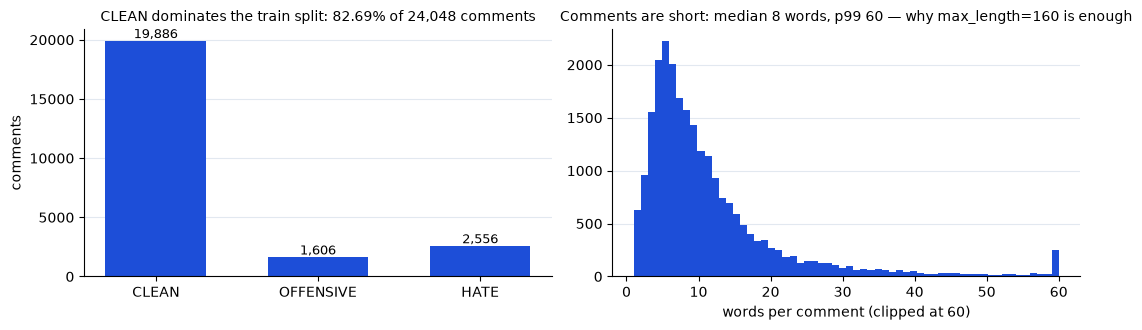

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

MARK = "#1d4ed8"
word_lengths = pd.Series([len(text.split()) for text in texts])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].bar(distribution["label"], distribution["count"], color=MARK, width=0.62)
axes[0].set_title(
    f"CLEAN dominates the {SPLIT} split: {distribution['share'].iloc[0]} of {total:,} comments",
    fontsize=10,
)
axes[0].set_ylabel("comments")
for label, count in zip(distribution["label"], distribution["count"], strict=True):
    axes[0].text(label, count, f"{count:,}", ha="center", va="bottom", fontsize=9)

axes[1].hist(word_lengths.clip(upper=60), bins=60, color=MARK)
axes[1].set_title(
    f"Comments are short: median {int(word_lengths.median())} words, "
    f"p99 {int(word_lengths.quantile(0.99))} — why max_length=160 is enough",
    fontsize=10,
)
axes[1].set_xlabel("words per comment (clipped at 60)")

for ax in axes:
    ax.grid(axis="y", color="#e2e8f0", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()


In [5]:
# Verbatim samples, two per class. The pipeline must not normalize raw text, so diacritics,
# emoji, teencode and repeated punctuation reach the model exactly as written.
sample_rows = []
for label_id, label in enumerate(LABEL_NAMES):
    for example in [item for item in examples if item.label == label_id][:2]:
        sample_rows.append({"label": f"{label_id} · {label}", "text": example.text[:140]})
display(pd.DataFrame(sample_rows))


,label,text
0,0 · CLEAN,Em được làm fan cứng luôn rồi nè ❤️ reaction q...
1,0 · CLEAN,Đậu Văn Cường giờ giống thằng sida hơn à
2,1 · OFFENSIVE,Lúp lúp như chó .
3,1 · OFFENSIVE,Dạy bơi cho cá. Bơi thì đương nhiên nó bơi đượ...
4,2 · HATE,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...
5,2 · HATE,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...


In [6]:
from sklearn.model_selection import StratifiedKFold

# The splitter the CLI builds internally, shown here so the fold geometry is auditable:
# every fold holds out the same proportion of each class, and both stages share these folds.
splitter = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
fold_plan = []
for fold, (train_idx, test_idx) in enumerate(splitter.split(texts, labels), start=1):
    held_out = Counter(labels[idx] for idx in test_idx)
    fold_plan.append(
        {
            "fold": fold,
            "train": len(train_idx),
            "held out": len(test_idx),
            **{
                f"held-out {label.lower()}": held_out.get(label_id, 0)
                for label_id, label in enumerate(LABEL_NAMES)
            },
        }
    )
print(f"StratifiedKFold(n_splits={FOLDS}, shuffle=True, random_state={SEED})")
pd.DataFrame(fold_plan)


StratifiedKFold(n_splits=5, shuffle=True, random_state=13)


,fold,train,held out,held-out clean,held-out offensive,held-out hate
0,1,19238,4810,3978,321,511
1,2,19238,4810,3977,321,512
2,3,19238,4810,3977,322,511
3,4,19239,4809,3977,321,511
4,5,19239,4809,3977,321,511


## Stage 2 — Classical baseline: TF-IDF + linear model

Per fold, everything is fit **inside the training fold only** (leak-free by construction):

```
TF-IDF words (1–2 grams, min_df=2)  ∪  TF-IDF chars (3–5 grams, min_df=2)
        └──>  LogisticRegression(class_weight="balanced")   or   LinearSVC(balanced)
```

`run_classical_cv` scores each held-out fold with `evaluate_fold`, which writes
`confusion_matrix_fold_<n>.json` as it goes. `LinearSVC` exposes no probabilities, so its ROC-AUC
and PR-AUC are reported as missing rather than approximated.


In [7]:
import time

from vihate.classical import ClassicalConfig, run_classical_cv

classical_results = {}
if not RUN_CLASSICAL:
    print("RUN_CLASSICAL = False — stage 2 skipped.")
else:
    for model in CLASSICAL_MODELS:
        out_dir = OUT_ROOT / f"classical_{model}"
        started = time.perf_counter()
        classical_results[model] = run_classical_cv(
            examples, ClassicalConfig(model=model, folds=FOLDS, seed=SEED), out_dir
        )
        macro_f1 = [result.scalars["macro_f1"] for result in classical_results[model]]
        print(
            f"{model:<7} {FOLDS} folds in {time.perf_counter() - started:5.1f}s   "
            f"macro_f1 per fold: {[round(value, 4) for value in macro_f1]}"
        )


logreg  5 folds in  66.0s   macro_f1 per fold: [0.6431, 0.6505, 0.6568, 0.6502, 0.6368]


svm     5 folds in  21.9s   macro_f1 per fold: [0.6498, 0.6652, 0.6531, 0.646, 0.6362]


In [8]:
HEADLINE_METRICS = (
    "macro_f1",
    "weighted_f1",
    "balanced_accuracy",
    "mcc",
    "roc_auc_ovr_weighted",
    "pr_auc_macro",
)


def fold_table(fold_results):
    # One row per fold. A metric a model cannot produce is marked "n/a" rather than
    # approximated (LinearSVC exposes no probabilities, so it has no ROC/PR-AUC).
    rows = []
    for result in fold_results:
        row = {"fold": result.fold}
        for metric in HEADLINE_METRICS:
            row[metric] = round(result.scalars[metric], 4) if metric in result.scalars else "n/a"
        rows.append(row)
    return pd.DataFrame(rows)


for model, fold_results in classical_results.items():
    print(f"classical / {model}")
    display(fold_table(fold_results))


classical / logreg


,fold,macro_f1,weighted_f1,balanced_accuracy,mcc,roc_auc_ovr_weighted,pr_auc_macro
0,1,0.6431,0.8525,0.6677,0.5287,0.9059,0.6617
1,2,0.6505,0.8578,0.6743,0.5446,0.9138,0.6779
2,3,0.6568,0.8577,0.6766,0.5431,0.9129,0.6837
3,4,0.6502,0.8572,0.6792,0.5469,0.9118,0.6707
4,5,0.6368,0.8514,0.6647,0.5301,0.9094,0.6538


classical / svm


,fold,macro_f1,weighted_f1,balanced_accuracy,mcc,roc_auc_ovr_weighted,pr_auc_macro
0,1,0.6498,0.8656,0.6238,0.5441,n/a,n/a
1,2,0.6652,0.8737,0.6360,0.5725,n/a,n/a
2,3,0.6531,0.8672,0.6256,0.5508,n/a,n/a
3,4,0.6460,0.8675,0.6201,0.5524,n/a,n/a
4,5,0.6362,0.8643,0.6127,0.5422,n/a,n/a


## Stage 3 — Transformer fine-tuning *(off by default: needs a GPU)*

Same folds, same seed, same metrics — only the backbone changes. Per fold: `AutoTokenizer`
(`max_length=160`, dynamic per-batch padding) + `AutoModelForSequenceClassification`, trained by
the Hugging Face `Trainer` with AdamW, a linear warmup schedule, `fp16` on CUDA, and a
cross-entropy loss **weighted by the training-fold class frequencies only**. Validation Macro F1
is recorded after every epoch to `training_history_fold_<n>.json`.

Set `RUN_TRANSFORMER = True` in the configuration cell and budget ~3–8 min per fold per model.
`uitnlp/visobert` fine-tunes fully with the defaults on a 4 GB GPU; for `xlm-roberta-base` also
set `TRANSFORMER_CONFIG["freeze_embeddings"] = True` (see `README_vihsd.md`).

CLI equivalent:

```bash
uv run vihate run --experiment transformer --model-name uitnlp/visobert --out-dir outputs/visobert
```


In [9]:
from vihate.transformer_cv import TransformerConfig, run_transformer_cv

transformer_results = {}
if not RUN_TRANSFORMER:
    print("RUN_TRANSFORMER = False — stage 3 skipped.")
    print("Published ViHSD Macro F1 reference points: classical TF-IDF 0.52-0.56 ·")
    print("PhoBERT-base 0.6476 · XLM-R base 0.6550 · ViSoBERT 0.6771 (SOTA).")
else:
    for backbone in TRANSFORMER_MODELS:
        slug = backbone.rsplit("/", 1)[-1]
        out_dir = OUT_ROOT / f"transformer_{slug}"
        started = time.perf_counter()
        transformer_results[backbone] = run_transformer_cv(
            examples,
            TransformerConfig(model_name=backbone, folds=FOLDS, seed=SEED, **TRANSFORMER_CONFIG),
            out_dir,
        )
        macro_f1 = [result.scalars["macro_f1"] for result in transformer_results[backbone]]
        print(
            f"{backbone} {FOLDS} folds in {time.perf_counter() - started:6.1f}s   "
            f"macro_f1 per fold: {[round(value, 4) for value in macro_f1]}"
        )


RUN_TRANSFORMER = False — stage 3 skipped.
Published ViHSD Macro F1 reference points: classical TF-IDF 0.52-0.56 ·
PhoBERT-base 0.6476 · XLM-R base 0.6550 · ViSoBERT 0.6771 (SOTA).


## Stage 4 — Output: summarize and write the run artifacts

`persist_fold_results` is **the same function the CLI calls** (`src/vihate/reporting.py`), so a
notebook run and a CLI run write the same files:

| File | Content |
|---|---|
| `fold_metrics.json` | every metric, per fold (machine-readable) |
| `summary.json` | mean ± population std across folds |
| `summary.md` | human-readable report of the same summary |
| `confusion_matrix_fold_<n>.json` | 3×3 matrix per fold — already written during scoring |
| `training_history_fold_<n>.json` | per-epoch loss + validation Macro F1 (transformer runs only) |


In [10]:
from vihate.reporting import persist_fold_results

all_runs = {
    f"classical_{model}": (OUT_ROOT / f"classical_{model}", fold_results)
    for model, fold_results in classical_results.items()
}
all_runs |= {
    f"transformer_{backbone.rsplit('/', 1)[-1]}": (
        OUT_ROOT / f"transformer_{backbone.rsplit('/', 1)[-1]}",
        fold_results,
    )
    for backbone, fold_results in transformer_results.items()
}

summaries = {}
for run_name, (out_dir, fold_results) in all_runs.items():
    summaries[run_name] = persist_fold_results(out_dir, fold_results)
    print(f"{run_name:<22} -> {out_dir.relative_to(REPO_ROOT)}/")

summary_table = pd.DataFrame(
    {
        run_name: {
            metric: f"{stats['mean']:.4f} ± {stats['std']:.4f}"
            for metric in HEADLINE_METRICS
            if (stats := summary.get(metric)) is not None
        }
        for run_name, summary in summaries.items()
    }
)
summary_table.index.name = "mean ± std over folds"
summary_table.fillna("n/a")   # a metric a model cannot produce is marked, never approximated


classical_logreg       -> outputs/notebook/classical_logreg/
classical_svm          -> outputs/notebook/classical_svm/


,classical_logreg,classical_svm
mean ± std over folds,,
macro_f1,0.6475 ± 0.0069,0.6501 ± 0.0095
weighted_f1,0.8553 ± 0.0028,0.8677 ± 0.0032
balanced_accuracy,0.6725 ± 0.0054,0.6236 ± 0.0076
mcc,0.5387 ± 0.0077,0.5524 ± 0.0108
roc_auc_ovr_weighted,0.9108 ± 0.0028,n/a
pr_auc_macro,0.6696 ± 0.0108,n/a


In [11]:
# Sizes are read from the absolute paths: the kernel's cwd is `notebooks/`, not the repo root.
artifacts = sorted(
    (path.relative_to(REPO_ROOT), path.stat().st_size)
    for path in OUT_ROOT.rglob("*")
    if path.is_file()
)
print(f"{len(artifacts)} artifact files under {OUT_ROOT.relative_to(REPO_ROOT)}/")
for path, size in artifacts:
    print(f"  {path}  ({size:,} bytes)")


16 artifact files under outputs/notebook/
  outputs/notebook/classical_logreg/confusion_matrix_fold_1.json  (154 bytes)
  outputs/notebook/classical_logreg/confusion_matrix_fold_2.json  (153 bytes)
  outputs/notebook/classical_logreg/confusion_matrix_fold_3.json  (154 bytes)
  outputs/notebook/classical_logreg/confusion_matrix_fold_4.json  (153 bytes)
  outputs/notebook/classical_logreg/confusion_matrix_fold_5.json  (154 bytes)
  outputs/notebook/classical_logreg/fold_metrics.json  (3,405 bytes)
  outputs/notebook/classical_logreg/summary.json  (1,342 bytes)
  outputs/notebook/classical_logreg/summary.md  (592 bytes)
  outputs/notebook/classical_svm/confusion_matrix_fold_1.json  (153 bytes)
  outputs/notebook/classical_svm/confusion_matrix_fold_2.json  (152 bytes)
  outputs/notebook/classical_svm/confusion_matrix_fold_3.json  (153 bytes)
  outputs/notebook/classical_svm/confusion_matrix_fold_4.json  (153 bytes)
  outputs/notebook/classical_svm/confusion_matrix_fold_5.json  (152 bytes)


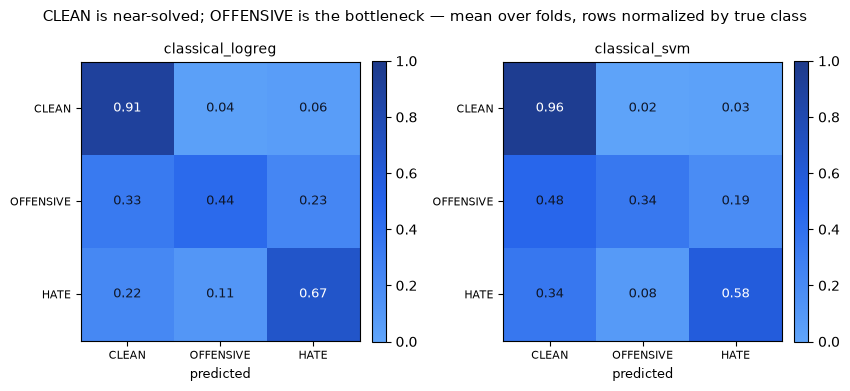

In [12]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Sequential ramp for an ordered magnitude. Every cell also prints its value, so nothing is
# encoded by colour alone.
RAMP = LinearSegmentedColormap.from_list("vihsd_blues", ["#60a5fa", "#2563eb", "#1e3a8a"])


def mean_confusion(fold_results):
    return np.array([result.confusion_matrix for result in fold_results], dtype=float).mean(axis=0)


if not all_runs:
    print("No stage ran — nothing to plot.")
else:
    fig, axes = plt.subplots(1, len(all_runs), figsize=(4.3 * len(all_runs), 3.9), squeeze=False)
    for ax, (run_name, (_, fold_results)) in zip(axes[0], all_runs.items(), strict=True):
        matrix = mean_confusion(fold_results)
        share = matrix / matrix.sum(axis=1, keepdims=True)  # each row = one true class
        image = ax.imshow(share, cmap=RAMP, vmin=0.0, vmax=1.0)
        ax.set_xticks(range(len(LABEL_NAMES)), LABEL_NAMES, fontsize=8)
        ax.set_yticks(range(len(LABEL_NAMES)), LABEL_NAMES, fontsize=8)
        ax.set_xlabel("predicted", fontsize=9)
        ax.set_title(run_name, fontsize=10)
        for row in range(len(LABEL_NAMES)):
            for col in range(len(LABEL_NAMES)):
                ax.text(
                    col,
                    row,
                    f"{share[row, col]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white" if share[row, col] > 0.55 else "#0f172a",
                )
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(
        "CLEAN is near-solved; OFFENSIVE is the bottleneck — mean over folds, "
        "rows normalized by true class",
        fontsize=11,
    )
    fig.tight_layout()
    plt.show()


## Stage 5 — Did the migration reproduce the project run?

A migration is only faithful if it lands on the numbers the project already accepted. The
reference below is the **HYPE-4 classical baseline** on the full `train` split
(`docs/project_overview_and_handover.md` §4.2), produced by the CLI and independently audited.

Small differences are expected — scikit-learn version drift moves Macro F1 in the third decimal
place. Anything beyond `TOLERANCE` means this notebook is no longer running the project run.


In [13]:
REFERENCE_MACRO_F1 = {
    "classical_logreg": 0.6475,   # ± 0.0069 across folds (HYPE-4)
    "classical_svm": 0.6501,      # ± 0.0095 across folds (HYPE-4)
}
TOLERANCE = 0.01

if SAMPLE_SIZE is not None:
    print(f"SAMPLE_SIZE={SAMPLE_SIZE}: smoke run, not comparable to the reference — check skipped.")
else:
    rows = []
    for run_name, reference in REFERENCE_MACRO_F1.items():
        summary = summaries.get(run_name)
        if summary is None:
            rows.append(
                {
                    "reference macro_f1": reference,
                    "notebook macro_f1": "n/a",
                    "delta": "n/a",
                    "verdict": "not run",
                }
            )
            continue
        observed = summary["macro_f1"]["mean"]
        delta = round(observed - reference, 4)
        rows.append(
            {
                "reference macro_f1": reference,
                "notebook macro_f1": round(observed, 4),
                "delta": delta if delta else 0.0,  # avoid "-0.0" on an exact match
                "verdict": "reproduced" if abs(observed - reference) <= TOLERANCE else "DRIFT",
            }
        )
    display(pd.DataFrame(rows, index=list(REFERENCE_MACRO_F1)))


,reference macro_f1,notebook macro_f1,delta,verdict
classical_logreg,0.6475,0.6475,0.0,reproduced
classical_svm,0.6501,0.6501,0.0,reproduced


## Outputs and next steps

**Output:** for each run, `outputs/notebook/<run>/` holds `fold_metrics.json`, `summary.json`,
`summary.md`, and one `confusion_matrix_fold_<n>.json` per fold — the same set the CLI writes.
`outputs/` is gitignored: attach run artifacts to the Multica issue instead of committing them.

Cross-check any notebook run against the CLI, which must produce identical files:

```bash
uv run vihate run --experiment classical                       --out-dir outputs/cli_logreg
uv run vihate run --experiment classical --classical-model svm  --out-dir outputs/cli_svm
diff outputs/cli_logreg/summary.json outputs/notebook/classical_logreg/summary.json
```

From here, the open work items are the ones the handover guide lists: **HYPE-5** (switch stage 3
on for `uitnlp/visobert` and `xlm-roberta-base` on a GPU machine) and **HYPE-6** (error analysis
over the per-fold confusion matrices this notebook already writes).

Keep these invariants intact — they are what make results comparable across the project:

- raw text is never modified;
- `StratifiedKFold(5, shuffle=True, random_state=13)` everywhere, classical and transformer alike;
- vectorizers, class weights, and transformer loss weights are fit on the training fold only;
- Macro F1 is the primary metric, reported as mean ± population std over folds, with unavailable
  metrics left blank rather than approximated.
